In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

In [1]:
import pandas as pd

df = pd.read_csv("Online Retail_data.csv", encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
print(df.shape)
print(df.columns)
df.info()
df.describe()

(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [15]:
print(df.isnull().sum())

InvoiceNo                       0
StockCode                       0
Description                     0
Quantity                        0
InvoiceDate                     0
UnitPrice                       0
CustomerID                      0
TotalPrice                      0
Country_Austria                 0
Country_Bahrain                 0
Country_Belgium                 0
Country_Brazil                  0
Country_Canada                  0
Country_Channel Islands         0
Country_Cyprus                  0
Country_Czech Republic          0
Country_Denmark                 0
Country_EIRE                    0
Country_European Community      0
Country_Finland                 0
Country_France                  0
Country_Germany                 0
Country_Greece                  0
Country_Iceland                 0
Country_Israel                  0
Country_Italy                   0
Country_Japan                   0
Country_Lebanon                 0
Country_Lithuania               0
Country_Malta 

In [21]:
df = df.drop_duplicates()
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER -0.183931   
1         536365     71053                  WHITE METAL LANTERN -0.183931   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER  0.010345   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE -0.183931   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART. -0.183931   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS  0.398897   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL  -0.183931   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL  -0.378208   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE -0.378208   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT  -0.475346   

               InvoiceDate  UnitPrice  CustomerID  TotalPrice  \
0      201

In [27]:
print("Missing values BEFORE imputation:")
print(df[['Quantity', 'UnitPrice']].isnull().sum())

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

df[['Quantity', 'UnitPrice']] = imputer.fit_transform(df[['Quantity', 'UnitPrice']])

print("\nMissing values AFTER imputation:")
print(df[['Quantity', 'UnitPrice']].isnull().sum())

Missing values BEFORE imputation:
Quantity     0
UnitPrice    0
dtype: int64

Missing values AFTER imputation:
Quantity     0
UnitPrice    0
dtype: int64


In [29]:
df1 = df[df['Quantity'] > 0]
df2 = df[df['UnitPrice'] > 0]
print(df1)
print(df2)

       InvoiceNo StockCode                          Description  Quantity  \
12        536367     22749    FELTCRAFT PRINCESS CHARLOTTE DOLL  0.010345   
88        536378     21033      JUMBO BAG CHARLIE AND LOLA TOYS  0.204621   
143       536382     21912             VINTAGE SNAKES & LADDERS  0.010345   
148       536382     22798     ANTIQUE GLASS DRESSING TABLE POT  0.010345   
159       536384     22457      NATURAL SLATE HEART CHALKBOARD   0.398897   
...          ...       ...                                  ...       ...   
541817    581579     22910    PAPER CHAIN KIT VINTAGE CHRISTMAS  0.398897   
541818    581579     22086      PAPER CHAIN KIT 50'S CHRISTMAS   0.398897   
541823    581579     23480       MINI LIGHTS WOODLAND MUSHROOMS  0.010345   
541879    581585     22726           ALARM CLOCK BAKELIKE GREEN  0.010345   
541890    581586     22061  LARGE CAKE STAND  HANGING STRAWBERY  0.010345   

               InvoiceDate  UnitPrice  CustomerID  TotalPrice  \
12     201

In [30]:
print("Before Conversion:")
print(df['InvoiceDate'].dtype)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\nAfter Conversion:")
print(df['InvoiceDate'].dtype)

Before Conversion:
datetime64[us]

After Conversion:
datetime64[us]


In [31]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

print(df[['InvoiceDate', 'Year', 'Month']].head())

            InvoiceDate  Year  Month
12  2010-12-01 08:34:00  2010     12
88  2010-12-01 09:37:00  2010     12
143 2010-12-01 09:45:00  2010     12
148 2010-12-01 09:45:00  2010     12
159 2010-12-01 09:53:00  2010     12


In [33]:
print("Before Cleaning:")
print("Negative Quantity:", (df['Quantity'] <= 0).sum())
print("Zero/Negative Price:", (df['UnitPrice'] <= 0).sum())
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print("\nAfter Cleaning:")
print("Negative Quantity:", (df['Quantity'] <= 0).sum())
print("Zero/Negative Price:", (df['UnitPrice'] <= 0).sum())


Before Cleaning:
Negative Quantity: 0
Zero/Negative Price: 0

After Cleaning:
Negative Quantity: 0
Zero/Negative Price: 0


In [34]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
df = df[(df['Quantity'] >= lower_bound) & (df['Quantity'] <= upper_bound)]
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['UnitPrice'] >= lower) & (df['UnitPrice'] <= upper)]

Lower Bound: -0.5724840055518189
Upper Bound: 0.9817260944223892


In [35]:
print(df.describe())

          Quantity                 InvoiceDate    UnitPrice    CustomerID  \
count  6405.000000                        6405  6405.000000   6405.000000   
mean      0.204181  2011-07-03 08:52:29.142857     0.192019  15001.390788   
min       0.010345         2010-12-01 08:34:00     0.048270  12347.000000   
25%       0.010345         2011-03-24 08:44:00     0.069142  13458.000000   
50%       0.204621         2011-07-28 14:03:00     0.069142  14911.000000   
75%       0.398897         2011-10-16 10:41:00     0.347445  16477.000000   
max       0.593174         2011-12-09 12:49:00     0.670972  18280.000000   
std       0.186431                         NaN     0.164752   1741.838460   

        TotalPrice         Year        Month  
count  6405.000000  6405.000000  6405.000000  
mean      2.232384  2010.903981     7.734426  
min       1.211064  2010.000000     1.000000  
25%       1.967138  2011.000000     5.000000  
50%       2.406716  2011.000000     9.000000  
75%       2.560569  2011

In [36]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(df[['Quantity', 'UnitPrice', 'TotalPrice']].head())

     Quantity  UnitPrice  TotalPrice
12   0.010345   0.347445    0.003594
88   0.204621   0.069142    0.014148
143  0.010345   0.347445    0.003594
148  0.010345   0.069142    0.000715
159  0.398897   0.069142    0.027581


In [37]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

print(df[['InvoiceDate', 'Year', 'Month']].head())

            InvoiceDate  Year  Month
12  2010-12-01 08:34:00  2010     12
88  2010-12-01 09:37:00  2010     12
143 2010-12-01 09:45:00  2010     12
148 2010-12-01 09:45:00  2010     12
159 2010-12-01 09:53:00  2010     12


In [38]:
print(df.select_dtypes(include='object').columns)

Index(['InvoiceNo', 'StockCode', 'Description'], dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_26224\2219242324.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


In [50]:
print(df.head())

     Quantity         InvoiceDate  UnitPrice  CustomerID  TotalPrice  \
12   0.010345 2010-12-01 08:34:00   0.347445     13047.0    0.003594   
88   0.204621 2010-12-01 09:37:00   0.069142     14688.0    0.014148   
143  0.010345 2010-12-01 09:45:00   0.347445     16098.0    0.003594   
148  0.010345 2010-12-01 09:45:00   0.069142     16098.0    0.000715   
159  0.398897 2010-12-01 09:53:00   0.069142     18074.0    0.027581   

     Country_Austria  Country_Bahrain  Country_Belgium  Country_Brazil  \
12             False            False            False           False   
88             False            False            False           False   
143            False            False            False           False   
148            False            False            False           False   
159            False            False            False           False   

     Country_Canada  ...  StockCode_85184C  StockCode_85185B  \
12            False  ...             False             Fal

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Quantity', 'UnitPrice', 'TotalPrice']] = scaler.fit_transform(
    df[['Quantity', 'UnitPrice', 'TotalPrice']]
)

print(df[['Quantity', 'UnitPrice', 'TotalPrice']].head())

     Quantity  UnitPrice  TotalPrice
12  -1.039805   0.943469   -0.753854
88   0.002359  -0.745883   -0.231005
143 -1.039805   0.943469   -0.753854
148 -1.039805  -0.745883   -0.896483
159  1.044523  -0.745883    0.434473


In [53]:
df.to_csv("cleaned_online_retail.csv", index=False)

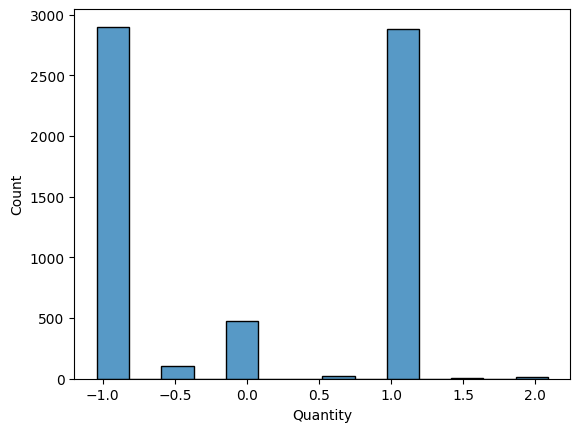

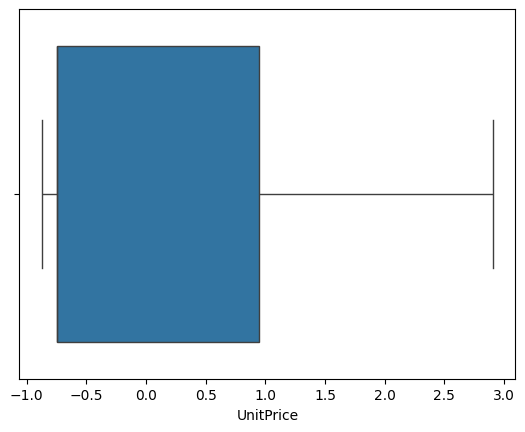

In [54]:
sns.histplot(df['Quantity'])
plt.show()

sns.boxplot(x=df['UnitPrice'])
plt.show()

<Axes: xlabel='TotalPrice', ylabel='Count'>

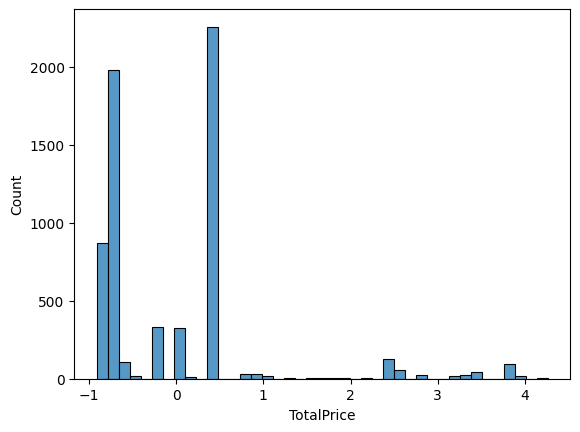

In [55]:
import seaborn as sns

sns.histplot(df['TotalPrice'])